In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [52]:
!pip install librosa torch seaborn --quiet
!pip install xgboost catboost --quiet
!pip install lightgbm --quiet
!pip install wandb --quiet

import wandb
import numpy as np
import pandas as pd
import os
import librosa
import librosa.display
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score,confusion_matrix,classification_report,accuracy_score

In [58]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

wandb_api = user_secrets.get_secret("Weights_and_biases_api")

os.environ["WANDB_API_KEY"] = wandb_api

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [5]:
DATA_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

GENRES_PATH = f"{DATA_PATH}/genres_stems"

ESC_PATH = f"{DATA_PATH}/ESC-50-master/audio"

GENRES = sorted(os.listdir(GENRES_PATH))

STEMS = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]

print("Genres:", GENRES)
print("Total genres:", len(GENRES))

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total genres: 10


In [6]:
noise_files = [
    f"{ESC_PATH}/{f}"
    for f in os.listdir(ESC_PATH)
    if f.endswith(".wav")
]

print("Noise files:",len(noise_files))

Noise files: 2000


# Dataset Exploration (EDA)

In [7]:
genre = "rock"
song_folder = os.listdir(f"{GENRES_PATH}/{genre}")[0]
file_path = f"{GENRES_PATH}/{genre}/{song_folder}/vocals.wav"
audio, sr = librosa.load(file_path, sr=None)
print(sr, len(audio)/sr)


44100 30.013333333333332


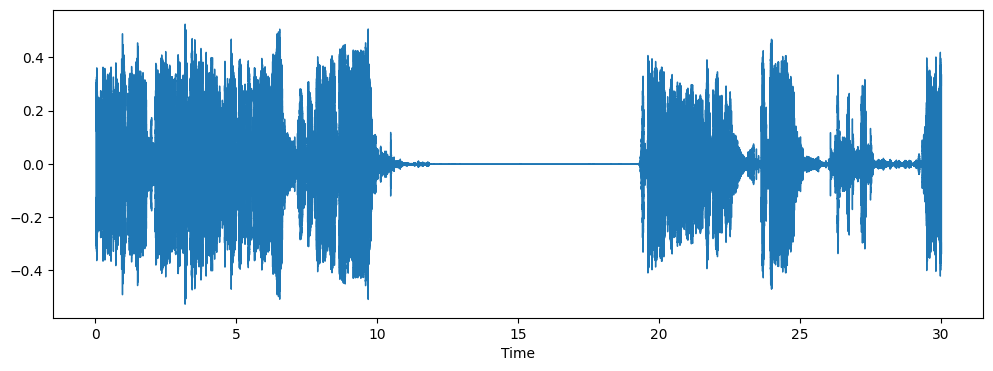

In [8]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)
plt.show()


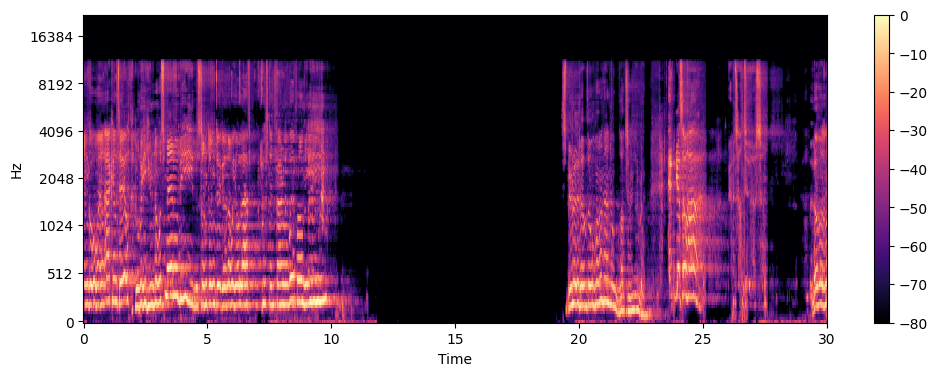

In [9]:
spec = librosa.feature.melspectrogram(y=audio, sr=sr)
spec_db = librosa.power_to_db(spec, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.show()


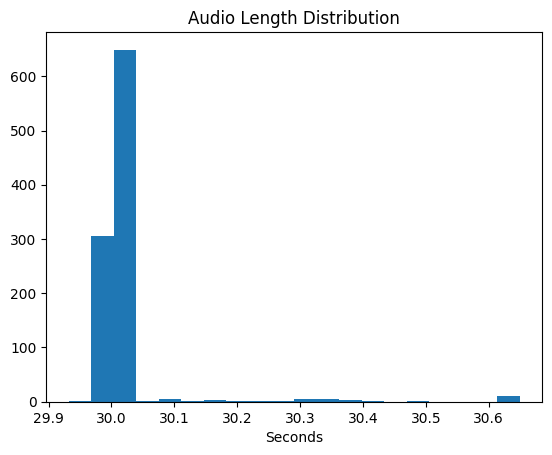

Mean length: 30.024047074829927


In [10]:
lengths = []

for genre in os.listdir(GENRES_PATH):
    songs = os.listdir(f"{GENRES_PATH}/{genre}")
    
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        if os.path.exists(path):
            audio, sr = librosa.load(path, sr=None)
            lengths.append(len(audio)/sr)

plt.hist(lengths, bins=20)
plt.title("Audio Length Distribution")
plt.xlabel("Seconds")
plt.show()

print("Mean length:", np.mean(lengths))


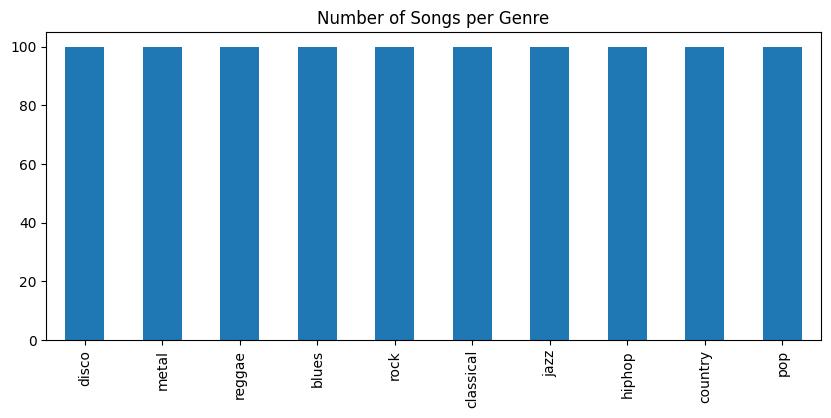

In [11]:
genre_counts = {}

for genre in os.listdir(GENRES_PATH):
    genre_counts[genre] = len(os.listdir(f"{GENRES_PATH}/{genre}"))

pd.Series(genre_counts).sort_values().plot(kind="bar", figsize=(10,4))
plt.title("Number of Songs per Genre")
plt.show()


In [12]:
sample_rates = []

for genre in os.listdir(GENRES_PATH):
    songs = os.listdir(f"{GENRES_PATH}/{genre}")[:10]
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        if os.path.exists(path):
            _, sr = librosa.load(path, sr=None)
            sample_rates.append(sr)

pd.Series(sample_rates).value_counts()


44100    100
Name: count, dtype: int64

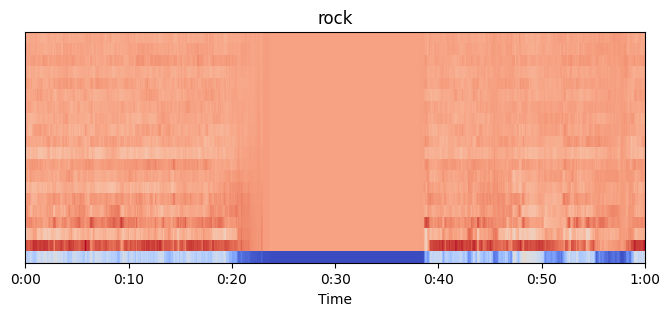

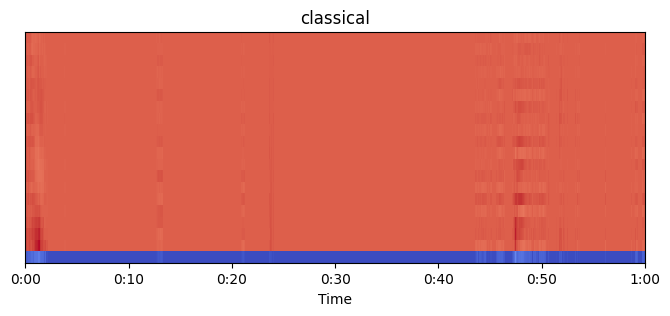

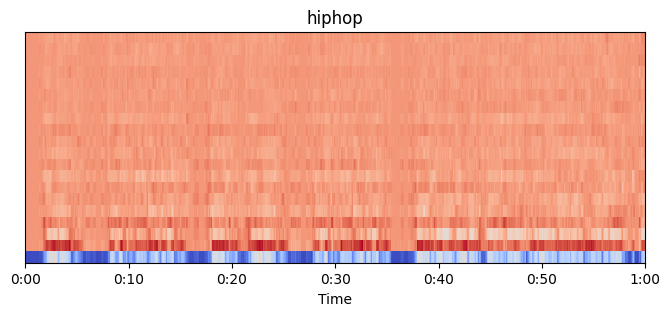

In [13]:
def plot_genre_mfcc(genre):
    song = os.listdir(f"{GENRES_PATH}/{genre}")[0]
    path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
    audio, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    
    plt.figure(figsize=(8,3))
    librosa.display.specshow(mfcc, x_axis='time')
    plt.title(genre)
    plt.show()

plot_genre_mfcc("rock")
plot_genre_mfcc("classical")
plot_genre_mfcc("hiphop")


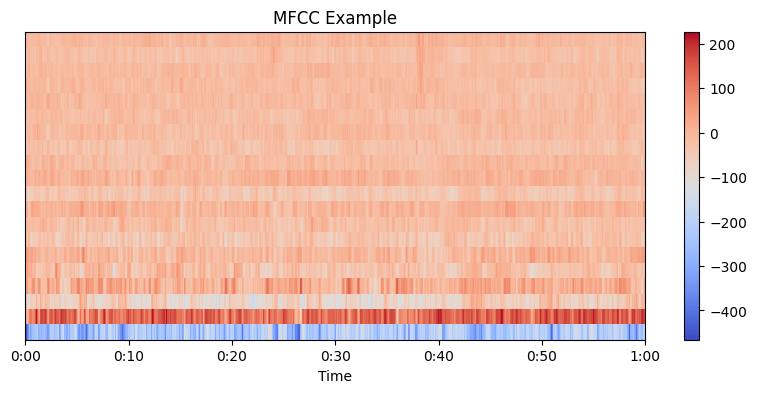

In [14]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Example")
plt.show()


In [15]:
silence_count=0

for genre in GENRES:

    songs=os.listdir(f"{GENRES_PATH}/{genre}")[:20]

    for song in songs:

        file=f"{GENRES_PATH}/{genre}/{song}/vocals.wav"

        y,sr=librosa.load(file,sr=None)

        if np.max(np.abs(y[:int(0.5*sr)]))<1e-4:

            silence_count+=1

print("Silence stems:",silence_count)

Silence stems: 20


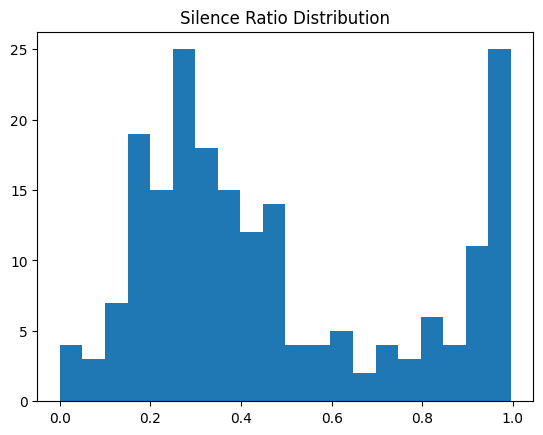

In [16]:
def silence_ratio(file_path):
    y, sr = librosa.load(file_path, sr=None)
    intervals = librosa.effects.split(y, top_db=20)
    voiced = sum((end-start) for start,end in intervals)
    return 1 - voiced/len(y)

ratios = []
for genre in os.listdir(GENRES_PATH):
    songs = os.listdir(f"{GENRES_PATH}/{genre}")[:20]
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        if os.path.exists(path):
            ratios.append(silence_ratio(path))

plt.hist(ratios, bins=20)
plt.title("Silence Ratio Distribution")
plt.show()


In [17]:
corrupted=0
small=0

for genre in GENRES:
    for song in os.listdir(f"{GENRES_PATH}/{genre}"):
        for stem in STEMS:
            fp=f"{GENRES_PATH}/{genre}/{song}/{stem}"

            if os.path.exists(fp):

                size=os.path.getsize(fp)

                if size<4096:
                    corrupted+=1

                if size<5*1024*1024:
                    small+=1

print("Corrupted files:",corrupted)
print("Small files:",small)

Corrupted files: 0
Small files: 0


100%|██████████| 200/200 [00:02<00:00, 73.50it/s]


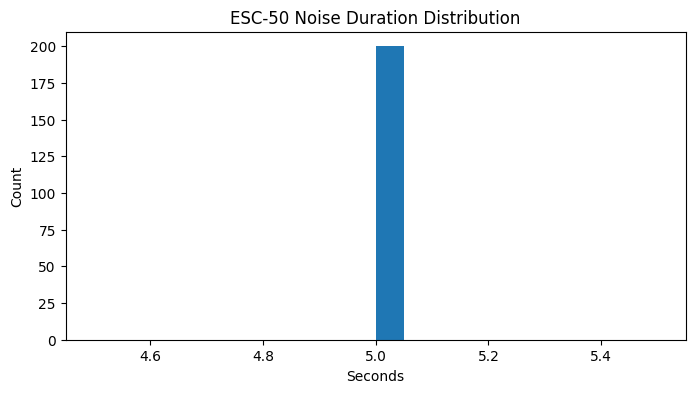

Mean noise length: 5.0
Sample rate distribution:
44100    200
Name: count, dtype: int64


In [18]:
noise_lengths = []
noise_sample_rates = []

for nf in tqdm(noise_files[:200]):   
    y, sr = librosa.load(nf, sr=None)
    noise_lengths.append(len(y)/sr)
    noise_sample_rates.append(sr)

plt.figure(figsize=(8,4))
plt.hist(noise_lengths, bins=20)
plt.title("ESC-50 Noise Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

print("Mean noise length:", np.mean(noise_lengths))
print("Sample rate distribution:")
print(pd.Series(noise_sample_rates).value_counts())

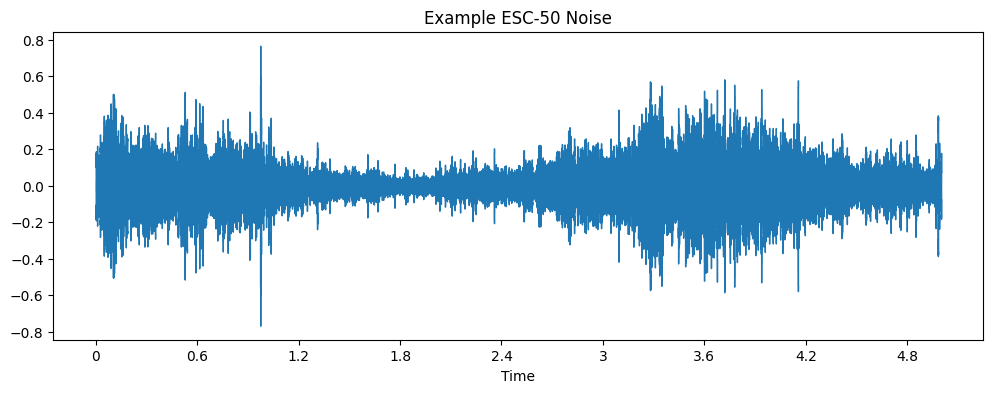

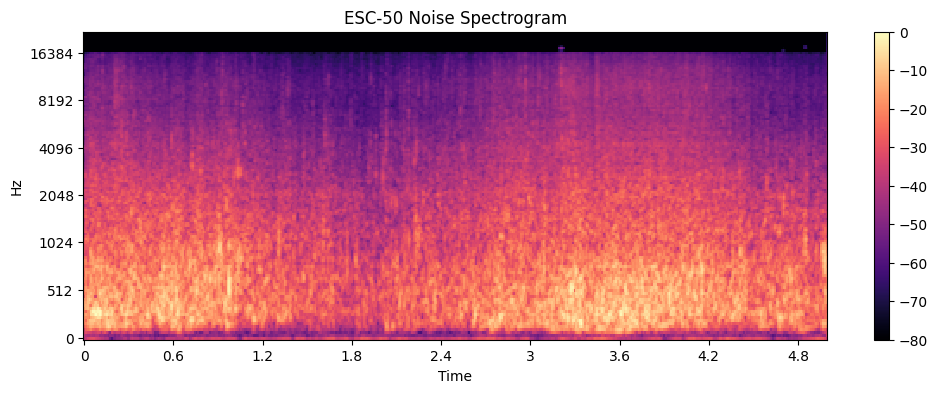

In [19]:
noise_example = np.random.choice(noise_files)

y, sr = librosa.load(noise_example, sr=None)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Example ESC-50 Noise")
plt.show()

spec = librosa.feature.melspectrogram(y=y, sr=sr)
spec_db = librosa.power_to_db(spec, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.title("ESC-50 Noise Spectrogram")
plt.colorbar()
plt.show()

In [20]:
missing = []

for genre in GENRES:
    songs = os.listdir(f"{GENRES_PATH}/{genre}")
    
    for song in songs:
        path = f"{GENRES_PATH}/{genre}/{song}"
        
        for stem in STEMS:
            fp = f"{path}/{stem}"
            
            if not os.path.exists(fp):
                missing.append(fp)

print("Missing stems:", len(missing))

Missing stems: 0


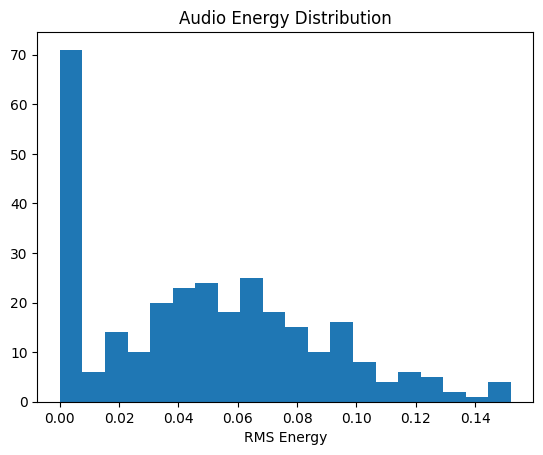

In [21]:
energy = []

for genre in GENRES:
    
    songs = os.listdir(f"{GENRES_PATH}/{genre}")[:30]
    
    for song in songs:
        
        file = f"{GENRES_PATH}/{genre}/{song}/vocals.wav"
        
        y, sr = librosa.load(file, sr=None)
        
        rms = np.mean(librosa.feature.rms(y=y))
        
        energy.append(rms)

plt.hist(energy, bins=20)
plt.title("Audio Energy Distribution")
plt.xlabel("RMS Energy")
plt.show()

In [22]:
test_df = pd.read_csv(f"{DATA_PATH}/test.csv")

print("Test samples:", len(test_df))

test_df.head()

Test samples: 3020


,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


### Dataset Observations

• The dataset contains 10 music genres: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, and rock.

• Each genre contains approximately 100 songs, indicating that the dataset is balanced across classes.

• The average audio length is around 30 seconds, with very little variation.

• All audio files share a sampling rate of 44.1 kHz.

• Each song contains four stems: drums, vocals, bass, and other. No missing stems were detected.

• The ESC-50 dataset provides 2000 environmental noise clips with an average duration of 5 seconds.

• Silence analysis shows that some audio segments contain large silent regions, which may need filtering during preprocessing.

• MFCC visualizations indicate different spectral patterns between genres, suggesting that spectral features can help distinguish music styles.

# Feature Extraction

In [23]:
SR = 22050

def extract_features(segment):

    segment = segment / (np.max(np.abs(segment)) + 1e-6)

    mfcc = librosa.feature.mfcc(y=segment, sr=SR, n_mfcc=40)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    delta_mean = np.mean(delta, axis=1)
    delta2_mean = np.mean(delta2, axis=1)

    chroma = librosa.feature.chroma_stft(y=segment, sr=SR)
    chroma_mean = np.mean(chroma, axis=1)

    contrast = librosa.feature.spectral_contrast(y=segment, sr=SR)
    contrast_mean = np.mean(contrast, axis=1)

    flatness = float(np.mean(librosa.feature.spectral_flatness(y=segment)))

    centroid = float(np.mean(librosa.feature.spectral_centroid(y=segment, sr=SR)))
    rolloff = float(np.mean(librosa.feature.spectral_rolloff(y=segment, sr=SR)))
    bandwidth = float(np.mean(librosa.feature.spectral_bandwidth(y=segment, sr=SR)))

    tempo,_ = librosa.beat.beat_track(y=segment, sr=SR)
    tempo = float(np.squeeze(tempo))

    rms = float(np.mean(librosa.feature.rms(y=segment)))
    zcr = float(np.mean(librosa.feature.zero_crossing_rate(segment)))

    flux = float(np.mean(librosa.onset.onset_strength(y=segment, sr=SR)))

    return np.concatenate([
        mfcc_mean,
        mfcc_std,
        delta_mean,
        delta2_mean,
        chroma_mean,
        contrast_mean,
        np.array([
            centroid,
            rolloff,
            bandwidth,
            tempo,
            flatness,
            rms,
            zcr,
            flux
        ])
    ])

In [24]:
noise_cache = []

for nf in tqdm(noise_files):
    y,_ = librosa.load(nf, sr=SR)
    noise_cache.append(y)

print("Loaded noise samples:",len(noise_cache))

100%|██████████| 2000/2000 [00:36<00:00, 55.32it/s]

Loaded noise samples: 2000


# Build Training Dataset

In [25]:
def random_stem_mix(genre):

    songs = os.listdir(f"{GENRES_PATH}/{genre}")

    stems_audio = []

    for stem in STEMS:

        song = random.choice(songs)

        file = f"{GENRES_PATH}/{genre}/{song}/{stem}"

        y_audio,_ = librosa.load(file, sr=SR)

        stems_audio.append(y_audio)

    min_len = min(len(s) for s in stems_audio)

    stems_audio = [s[:min_len] for s in stems_audio]

    mix = np.mean(stems_audio, axis=0)

    return mix

In [33]:
X=[]
y=[]
song_ids=[]

SEGMENT_DURATION=5
HOP_DURATION=2.5

segment_len=int(SEGMENT_DURATION*SR)
hop_len=int(HOP_DURATION*SR)

for genre in GENRES:

    songs=os.listdir(f"{GENRES_PATH}/{genre}")

    for song in tqdm(songs):

        song_path=f"{GENRES_PATH}/{genre}/{song}"

        song_id=f"{genre}_{song}"

        if np.random.rand() < 0.5:

            signals=[
                librosa.load(f"{song_path}/{stem}", sr=SR)[0]
                for stem in STEMS
            ]

            mix=np.mean(signals,axis=0)

        else:

            mix=random_stem_mix(genre)


        start=0

        while start+segment_len<=len(mix):

            segment=mix[start:start+segment_len]

            start+=hop_len

            if np.max(np.abs(segment))<1e-4:
                continue

            segment=segment/(np.max(np.abs(segment))+1e-6)

            try:

                feat=extract_features(segment)

                X.append(feat)
                y.append(genre)
                song_ids.append(song_id)

            except:
                continue


            # noise augmentation
            for _ in range(3):

                noise=random.choice(noise_cache)

                max_start=len(noise)-segment_len

                if max_start<=0:
                    continue

                idx=np.random.randint(0,max_start)

                noise_segment=noise[idx:idx+segment_len]

                noise_segment=noise_segment/(np.max(np.abs(noise_segment))+1e-6)

                noise_strength=np.random.uniform(0.05,0.2)

                noisy_segment=segment+noise_strength*noise_segment

                noisy_segment=noisy_segment/(np.max(np.abs(noisy_segment))+1e-6)

                try:

                    feat_noise=extract_features(noisy_segment)

                    X.append(feat_noise)
                    y.append(genre)
                    song_ids.append(song_id)

                except:
                    continue


X=np.array(X)
y=np.array(y)
song_ids=np.array(song_ids)

print("Dataset size:",X.shape)

100%|██████████| 100/100 [02:08<00:00,  1.28s/it]

Dataset size: (10980, 187)


## Classical ML

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [35]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, val_idx = next(gss.split(X, y, groups=song_ids))

X_train = X[train_idx]
X_val = X[val_idx]

y_train = y_encoded[train_idx]
y_val = y_encoded[val_idx]

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_val)

lr_f1 = f1_score(y_val, lr_preds, average="macro")

print("Logistic Regression Macro F1:", lr_f1)

Logistic Regression Macro F1: 0.6799563056133947


In [38]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_val)

nb_f1 = f1_score(y_val, nb_preds, average="macro")

print("Naive Bayes Macro F1:", nb_f1)

Naive Bayes Macro F1: 0.5154913164368433


In [39]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=64
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_val)

lgb_f1 = f1_score(y_val, lgb_preds, average="macro")

print("LightGBM Macro F1:", lgb_f1)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009054 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47475
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 187
[LightGBM] [Info] Start training from score -2.300993
[LightGBM] [Info] Start training from score -2.221300
[LightGBM] [Info] Start training from score -2.398806
[LightGBM] [Info] Start training from score -2.313572
[LightGBM] [Info] Start training from score -2.243582
[LightGBM] [Info] Start training from score -2.326311
[LightGBM] [Info] Start training from score -2.365531
[LightGBM] [Info] Start training from score -2.217111
[LightGBM] [Info] Start training from score -2.339214
[LightGBM] [Info] Start training from score -2.315876
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Macro F1: 0.7274137698065101


In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=10,
    tree_method="hist",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_val)

xgb_f1 = f1_score(y_val, xgb_preds, average="macro")

print("XGBoost Macro F1:", xgb_f1)


XGBoost Macro F1: 0.7246187582987598


In [43]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    verbose=False
)

cat.fit(X_train, y_train)

cat_preds = cat.predict(X_val)

cat_f1 = f1_score(y_val, cat_preds, average="macro")

print("CatBoost Macro F1:", cat_f1)


CatBoost Macro F1: 0.716042030235293


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "LightGBM",
        "XGBoost",
        "CatBoost"
    ],
    "Macro F1": [
        lr_f1,
        nb_f1,
        lgb_f1,
        xgb_f1,
        cat_f1
    ]
})

results = results.sort_values("Macro F1", ascending=False)

results

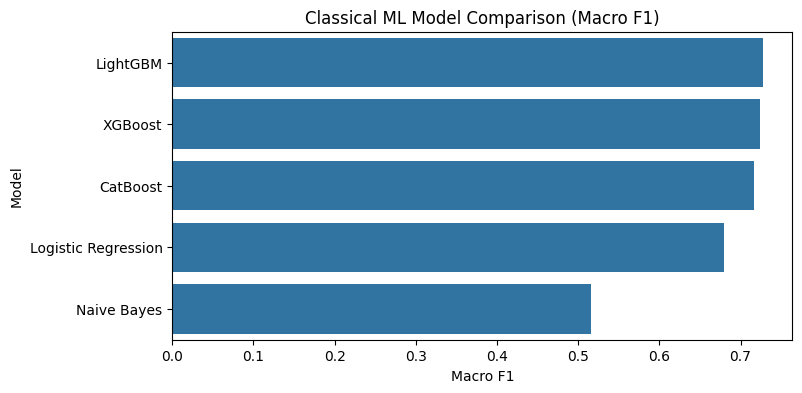

In [45]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results,
    x="Macro F1",
    y="Model"
)

plt.title("Classical ML Model Comparison (Macro F1)")
plt.show()

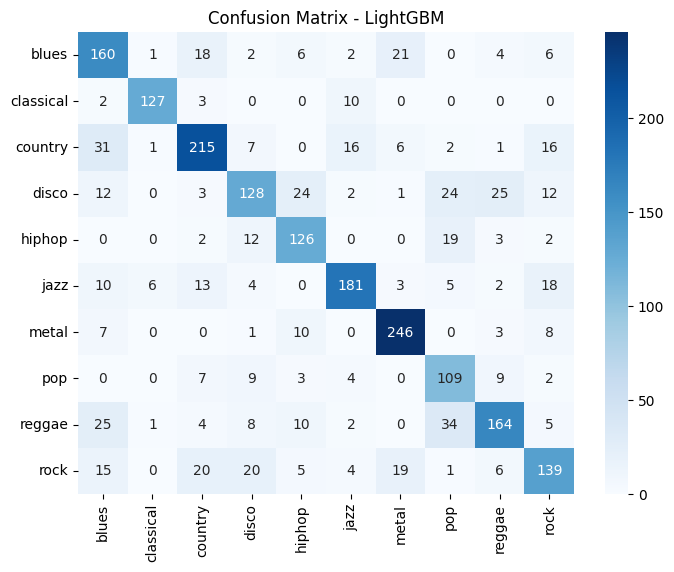

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, lgb_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - LightGBM")
plt.show()

In [49]:
X_test = []

for fname in tqdm(test_df["filename"]):

    file_path = f"{DATA_PATH}/{fname}"

    y_audio,_ = librosa.load(file_path, sr=SR)

    segment_len = SEGMENT_DURATION * SR

    segments = len(y_audio) // segment_len

    feats = []

    for i in range(segments):

        segment = y_audio[
            i*segment_len:(i+1)*segment_len
        ]

        feat = extract_features(segment)

        feats.append(feat)

    X_test.append(np.mean(feats, axis=0))

X_test = scaler.transform(np.array(X_test))

100%|██████████| 3020/3020 [27:50<00:00,  1.81it/s]


In [60]:
import wandb

wandb.init(
    project="24f1001527-t12026",
    name="classical_ml_baseline"
)
wandb.log({
    "LogisticRegression_F1": lr_f1,
    "NaiveBayes_F1": nb_f1,
    "LightGBM_F1": lgb_f1,
    "XGBoost_F1": xgb_f1,
    "CatBoost_F1": cat_f1
})

wandb.log({"Model Comparison": wandb.Table(dataframe=results)})

wandb.finish()

CatBoost_F1,▁
LightGBM_F1,▁
LogisticRegression_F1,▁
NaiveBayes_F1,▁
XGBoost_F1,▁
CatBoost_F1,0.71604
LightGBM_F1,0.72741
LogisticRegression_F1,0.67996
NaiveBayes_F1,0.51549
XGBoost_F1,0.72462


In [61]:
preds = lgb_model.predict(X_test)

pred_labels = le.inverse_transform(preds)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [62]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": pred_labels
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,genre
0,1,pop
1,2,pop
2,3,country
3,4,rock
4,5,country


# Milestone 1


In [ ]:
# import os
# import glob
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# import librosa
# import librosa.display
# import matplotlib.pyplot as plt
# import random
# import torch
# import warnings
# warnings.filterwarnings("ignore")


# DATA_SEED = 67
# TRAINING_SEED = 1234
# SR = 22050
# DURATION = 5.0
# N_FFT = 2048
# HOP_LENGTH = 512
# N_MELS = 128
# TOP_DB=20
# TARGET_SNR_DB = 10

# random.seed(DATA_SEED)
# np.random.seed(DATA_SEED)
# torch.manual_seed(DATA_SEED)

# DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
# GENRES_ROOT = f"{DATA_ROOT}/genres_stems"

# GENRES = sorted(os.listdir(GENRES_ROOT))
# STEMS = {"drums.wav":"drums","vocals.wav":"vocals","bass.wav":"bass","other.wav":"other"}
# STEM_KEYS = ['drums','vocals','bass','other']

# GENRE_TO_TEST = 'rock'
# SONG_INDEX = 0


# def build_dataset(root_dir, val_split=0.17, seed=42):
#     train_dataset = {g: {k: [] for k in STEM_KEYS} for g in GENRES}
#     val_dataset   = {g: {k: [] for k in STEM_KEYS} for g in GENRES}
    
#     rng = random.Random(seed)
#     corrupted_count = 0
#     small_count = 0
#     large_count = 0
    
#     for genre in GENRES:
#         genre_path = os.path.join(root_dir,"genres_stems",genre)
#         songs = sorted(os.listdir(genre_path))
#         valid_songs = []
        
#         for song in songs:
#             song_path = os.path.join(genre_path,song)
#             valid=True
            
#             for stem_file in STEMS.keys():
#                 fp = os.path.join(song_path,stem_file)
                
#                 if not os.path.exists(fp):
#                     valid=False
#                 else:
#                     size=os.path.getsize(fp)
                    
#                     if size < 4*1024:
#                         corrupted_count+=1
#                         valid=False
                    
#                     size_mb=size/(1024*1024)
#                     if size_mb < 5.0491: small_count+=1
#                     if size_mb > 5.0493: large_count+=1
            
#             if valid:
#                 valid_songs.append(song)
        
#         rng.shuffle(valid_songs)
#         split=int(len(valid_songs)*(1-val_split))
#         train_songs=valid_songs[:split]
#         val_songs=valid_songs[split:]
        
#         for s in train_songs:
#             for stem_file,stem_key in STEMS.items():
#                 train_dataset[genre][stem_key].append(
#                     os.path.join(genre_path,s,stem_file))
        
#         for s in val_songs:
#             for stem_file,stem_key in STEMS.items():
#                 val_dataset[genre][stem_key].append(
#                     os.path.join(genre_path,s,stem_file))
    
#     Q1 = corrupted_count + small_count
#     Q2 = abs(large_count - small_count)
#     Q3 = abs(len(train_dataset["reggae"]["drums"]) - len(val_dataset["country"]["vocals"]))
    
#     return train_dataset, val_dataset, Q1, Q2, Q3

# tr, val, Q1, Q2, Q3 = build_dataset(DATA_ROOT)

In [ ]:
# def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):
#     records = []

#     for genre in dataset_dict:
#         for stem in dataset_dict[genre]:
#             for file_path in dataset_dict[genre][stem]:

#                 y, _ = librosa.load(file_path, sr=sr)

#                 total_duration = len(y) / sr

#                 rms = librosa.feature.rms(
#                     y=y,
#                     frame_length=N_FFT,
#                     hop_length=HOP_LENGTH
#                 )[0]

#                 rms_db = librosa.amplitude_to_db(rms, ref=np.max)

#                 silent_frames = rms_db < -top_db

#                 silence_lengths = []
#                 count = 0

#                 for val in silent_frames:
#                     if val:
#                         count += 1
#                     else:
#                         if count > 0:
#                             silence_lengths.append(count * HOP_LENGTH / sr)
#                             count = 0

#                 if count > 0:
#                     silence_lengths.append(count * HOP_LENGTH / sr)

#                 if len(silence_lengths) == 0:
#                     continue

#                 max_silence = max(silence_lengths)

#                 if max_silence >= threshold_sec:

#                     silence_type = []

#                     if silence_lengths[0] >= threshold_sec:
#                         silence_type.append("start")

#                     if silence_lengths[-1] >= threshold_sec:
#                         silence_type.append("end")

#                     if max_silence >= threshold_sec and not silence_type:
#                         silence_type.append("middle")

#                     records.append({
#                         "Genre": genre,
#                         "Stem": stem,
#                         "Duration": round(total_duration, 2),
#                         "Max_Silence_Sec": round(max_silence, 2),
#                         "Silence_Location": ", ".join(silence_type),
#                         "File_Path": file_path
#                     })

#     columns = ["Genre","Stem","Duration","Max_Silence_Sec","Silence_Location","File_Path"]
#     return pd.DataFrame(records, columns=columns)


In [ ]:
# df_silence = find_long_silences(tr)


# Q4=len(df_silence)
# Q5=len(df_silence[df_silence["Stem"]=="vocals"])
# Q6=df_silence[df_silence["Stem"]=="vocals"]["Max_Silence_Sec"].mean()
# Q7=len(df_silence[(df_silence["Genre"]=="jazz") & (df_silence["Stem"]=="drums")])
# Q8=len(df_silence[(df_silence["Genre"]=="jazz") & (df_silence["Stem"]=="drums") & (df_silence["Silence_Location"]=="middle")])
# Q9=len(df_silence[(df_silence["Genre"]=="jazz") & (df_silence["Stem"]=="drums") & (df_silence["Max_Silence_Sec"]>=10)])


# stems_audio = []
# for key in STEM_KEYS:
#     file_path = tr[GENRE_TO_TEST][key][SONG_INDEX]
#     y, _ = librosa.load(file_path, sr=SR, duration=DURATION)
#     stems_audio.append(y)

# stems_stack = np.vstack(stems_audio)

# mix_raw = np.sum(stems_stack, axis=0)

# rms_val = np.sqrt(np.mean(mix_raw ** 2))

# peak_raw = np.max(np.abs(mix_raw))

# mix_norm = mix_raw / peak_raw if peak_raw > 0 else mix_raw

# Q10=len(mix_raw)
# Q11=rms_val
# Q12=np.max(np.abs(mix_raw))


# print("\nFINAL ANSWERS:")
# print("Q1:",Q1)
# print("Q2:",Q2)
# print("Q3:",Q3)
# print("Q4:",Q4)
# print("Q5:",Q5)
# print("Q6:",Q6)
# print("Q7:",Q7)
# print("Q8:",Q8)
# print("Q9:",Q9)
# print("Q10:",Q10)
# print("Q11:",Q11)
# print("Q12:",Q12)

## Milestone 2

In [ ]:
# ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
# STEMS_PATH = f"{ROOT}/genres_stems"
# NOISE_PATH = f"{ROOT}/ESC-50-master/audio"
# MASHUPS_PATH = f"{ROOT}/mashups"

# GENRES = ["blues","classical","country","disco","hiphop",
#           "jazz","metal","pop","reggae","rock"]

In [ ]:

# durations=[]

# for song in os.listdir(f"{STEMS_PATH}/jazz"):

#     song_path=f"{STEMS_PATH}/jazz/{song}"

#     for stem in ["drums.wav","vocals.wav","bass.wav","other.wav"]:

#         file=f"{song_path}/{stem}"

#         if os.path.exists(file):

#             y,sr=librosa.load(file,sr=None)

#             durations.append(len(y)/sr)

# print("Q1 Mean Jazz Duration:",np.mean(durations))



# sample_rates=set()

# for root,_,files in os.walk(ROOT):

#     for f in files:

#         if f.endswith(".wav"):

#             file=os.path.join(root,f)

#             try:
#                 _,sr=librosa.load(file,sr=None)
#                 sample_rates.add(sr)
#             except:
#                 pass

# print("Q2 Sample Rates:",sorted(sample_rates))



# empty_files=0

# for root,_,files in os.walk(STEMS_PATH):

#     for f in files:

#         if f.endswith(".wav"):

#             file=os.path.join(root,f)

#             if os.path.getsize(file)==0:

#                 empty_files+=1

# print("Q3 Empty Files:",empty_files)


# db_vals=[]

# for g in GENRES:

#     for song in os.listdir(f"{STEMS_PATH}/{g}"):

#         file=f"{STEMS_PATH}/{g}/{song}/vocals.wav"

#         if os.path.exists(file):

#             y,sr=librosa.load(file,sr=None)

#             peak=np.max(np.abs(y))

#             db=20*np.log10(peak+1e-9)

#             db_vals.append(db)

# print("Q4 Vocal Peak dB:",np.mean(db_vals))


# centroids=[]

# for song in os.listdir(f"{STEMS_PATH}/blues"):

#     file=f"{STEMS_PATH}/blues/{song}/other.wav"

#     if os.path.exists(file):

#         y,sr=librosa.load(file,sr=None)

#         c=np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))

#         centroids.append(c)

# print("Q5 Blues Centroid:",np.mean(centroids))



# genre_centroids={}

# for g in GENRES:

#     vals=[]

#     for song in os.listdir(f"{STEMS_PATH}/{g}"):

#         file=f"{STEMS_PATH}/{g}/{song}/other.wav"

#         if os.path.exists(file):

#             y,sr=librosa.load(file,sr=None)

#             c=np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))

#             vals.append(c)

#     genre_centroids[g]=np.mean(vals)

# print("Q6 Highest Centroid Genre:",
#       max(genre_centroids,key=genre_centroids.get))



# silence_count=0

# for g in GENRES:

#     for song in os.listdir(f"{STEMS_PATH}/{g}"):

#         for stem in ["drums.wav","vocals.wav","bass.wav","other.wav"]:

#             file=f"{STEMS_PATH}/{g}/{song}/{stem}"

#             if os.path.exists(file):

#                 y,sr=librosa.load(file,sr=None,duration=0.5)

#                 if np.max(np.abs(y))<1e-4:

#                     silence_count+=1

# print("Q7 Silence Stems:",silence_count)

In [ ]:

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import f1_score,confusion_matrix,classification_report

# GENRES = ["blues","classical","country","disco","hiphop",
#           "jazz","metal","pop","reggae","rock"]


# def extract_dt_features(song_path):

#     y,sr=librosa.load(f"{song_path}/other.wav",
#                       sr=22050,
#                       duration=10)

#     tempo,_=librosa.beat.beat_track(y=y,sr=sr)

#     spec_cent=np.mean(
#         librosa.feature.spectral_centroid(y=y,sr=sr)
#     )

#     zcr=np.mean(
#         librosa.feature.zero_crossing_rate(y)
#     )

#     rolloff=np.mean(
#         librosa.feature.spectral_rolloff(y=y,sr=sr)
#     )

#     return [float(tempo),spec_cent,zcr,rolloff]


# data=[]

# for g in GENRES:

#     gp=f"{STEMS_PATH}/{g}"

#     songs=os.listdir(gp)

#     for s in songs[:50]:

#         data.append({
#             "path":f"{gp}/{s}",
#             "genre":g
#         })

# df=pd.DataFrame(data)

# train_df,val_df=train_test_split(
#     df,
#     test_size=0.2,
#     stratify=df['genre'],
#     random_state=42
# )


# X_train=np.array([
#     extract_dt_features(p)
#     for p in train_df['path']
# ])

# y_train=train_df['genre']


# X_val=np.array([
#     extract_dt_features(p)
#     for p in val_df['path']
# ])

# y_val=val_df['genre']


# clf=DecisionTreeClassifier(
#     max_depth=5,
#     random_state=42
# )

# clf.fit(X_train,y_train)

In [ ]:
# y_pred=clf.predict(X_val)
# macro_f1=f1_score(
#     y_val,
#     y_pred,
#     average='macro'
# )
# cm=confusion_matrix(
#     y_val,
#     y_pred,
#     labels=GENRES
# )
# cr=classification_report(
#     y_val,
#     y_pred
# )
# print("Macro F1:",macro_f1)
# print("\nClassification Report\n")
# print(cr)

In [ ]:
# import seaborn as sns

# plt.figure(figsize=(10,8))

# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     xticklabels=GENRES,
#     yticklabels=GENRES
# )

# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix")

# plt.show()

In [ ]:
# from sklearn.metrics import accuracy_score

# accuracy=accuracy_score(y_val,y_pred)

# print("Accuracy:",accuracy)


# tp={}
# fn={}

# total=np.sum(cm)

# for i,g in enumerate(GENRES):

#     TP=cm[i,i]

#     FN=np.sum(cm[i,:])-TP

#     tp[g]=TP
#     fn[g]=FN


# print("Highest TP:",max(tp,key=tp.get))

# print("Lowest FN:",min(fn,key=fn.get))

Milestone 4

In [ ]:
# import torch
# import torch.nn as nn
# import torchaudio
# import math
# import wandb
# x = torch.randn(32,1,64,64)
# flatten = torch.flatten(x, start_dim=1)
# print("Flatten shape:", flatten.shape)
# print("Linear input size:", flatten.shape[1])
# waveform = torch.randn(1,16000)
# mel = torchaudio.transforms.MelSpectrogram(
#     sample_rate=16000,
#     n_fft=400,
#     hop_length=160,
#     n_mels=64
# )
# mel_spec = mel(waveform)
# print("Mel spectrogram shape:", mel_spec.shape)
# conv = nn.Conv2d(1,16,kernel_size=3,stride=1,padding=1)
# pool = nn.MaxPool2d(kernel_size=2,stride=2)
# input_tensor = torch.randn(1,1,64,64)
# out = conv(input_tensor)
# out = pool(out)
# print("CNN output shape:", out.shape)
# layer = nn.Linear(128,64)
# params = sum(p.numel() for p in layer.parameters())
# print("Linear parameters:", params)
# dataset_size = 1050
# batch_size = 32
# batches = math.ceil(dataset_size/batch_size)
# print("Batches per epoch:", batches)
# logits = torch.tensor([[2.5,1.0,0.1]])
# target = torch.tensor([0])
# criterion = nn.CrossEntropyLoss()
# loss = criterion(logits,target)
# print("CrossEntropy loss:", loss.item())
# w = 0.5
# grad = 0.2
# lr = 0.01
# w_new = w - lr*grad
# print("Updated weight:", w_new)
# kernel = 5
# padding = (kernel-1)//2
# print("Required padding:", padding)
# wandb.init(project="demo")
# loss = 0.25
# accuracy = 0.85
# wandb.log({"loss":loss,"acc":accuracy})
# wandb.finish()
# correct = 170
# total = 200
# accuracy = correct/total
# print("Accuracy:", accuracy)